# House Price Prediction

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [10]:
# Load dataset
df = pd.read_csv(r"C:\Users\amans\Downloads\data (1).csv")   # change file name if needed

# View data
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


# Data cleaning 

In [6]:
# Check missing values
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [20]:
# Fill missing values
df.fillna(0)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [26]:
# Remove duplicates
df.drop_duplicates(inplace=False)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
10,2014-05-02 00:00:00,463000.0,3.0,1.75,1710,7320,1.0,0,0,3,1710,0,1948,1994,Burke-Gilman Trail,Lake Forest Park,WA 98155,USA
12,2014-05-02 00:00:00,588500.0,3.0,1.75,2330,14892,1.0,0,0,3,1970,360,1980,0,1833 220th Pl NE,Sammamish,WA 98074,USA
17,2014-05-02 00:00:00,367500.0,4.0,3.00,3110,7231,2.0,0,0,3,3110,0,1997,0,11224 SE 306th Pl,Auburn,WA 98092,USA


In [28]:
df.drop_duplicates(inplace=True)

In [69]:
# Description
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
count,4.400000e+01,44.000000,44.000000,44.000000,44.000000,44.000000,44.0,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,5.720665e+05,3.522727,2.142045,2117.045455,24575.886364,1.443182,0.0,0.181818,3.568182,1940.909091,176.136364,1970.250000,863.318182,21.500000
std,5.201721e+05,0.952076,0.596496,873.513567,51504.728818,0.472695,0.0,0.724095,0.728098,910.611392,304.533314,25.266142,1001.763788,12.845233
min,1.000000e+05,2.000000,1.000000,810.000000,3000.000000,1.000000,0.0,0.000000,3.000000,810.000000,0.000000,1909.000000,0.000000,0.000000
25%,2.780000e+05,3.000000,1.750000,1462.500000,8282.000000,1.000000,0.0,0.000000,3.000000,1287.500000,0.000000,1955.750000,0.000000,10.750000
50%,4.225000e+05,3.000000,2.125000,1965.000000,11042.000000,1.250000,0.0,0.000000,3.000000,1615.000000,0.000000,1975.500000,0.000000,21.500000
75%,6.168750e+05,4.000000,2.500000,2715.000000,15435.000000,2.000000,0.0,0.000000,4.000000,2687.500000,320.000000,1989.500000,2000.250000,32.250000
max,2.384000e+06,6.000000,4.000000,4510.000000,327135.000000,2.000000,0.0,4.000000,5.000000,4510.000000,1000.000000,2006.000000,2014.000000,43.000000


# Encode Categorical Data

In [77]:
le = LabelEncoder()

df['city'] = le.fit_transform(df['city'])
le

LabelEncoder()

In [39]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 2064
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          44 non-null     float64
 1   bedrooms       44 non-null     float64
 2   bathrooms      44 non-null     float64
 3   sqft_living    44 non-null     int64  
 4   sqft_lot       44 non-null     int64  
 5   floors         44 non-null     float64
 6   waterfront     44 non-null     int64  
 7   view           44 non-null     int64  
 8   condition      44 non-null     int64  
 9   sqft_above     44 non-null     int64  
 10  sqft_basement  44 non-null     int64  
 11  yr_built       44 non-null     int64  
 12  yr_renovated   44 non-null     int64  
 13  city           44 non-null     int32  
dtypes: float64(4), int32(1), int64(9)
memory usage: 6.0 KB


# Exploratory Data Analysis (EDA)

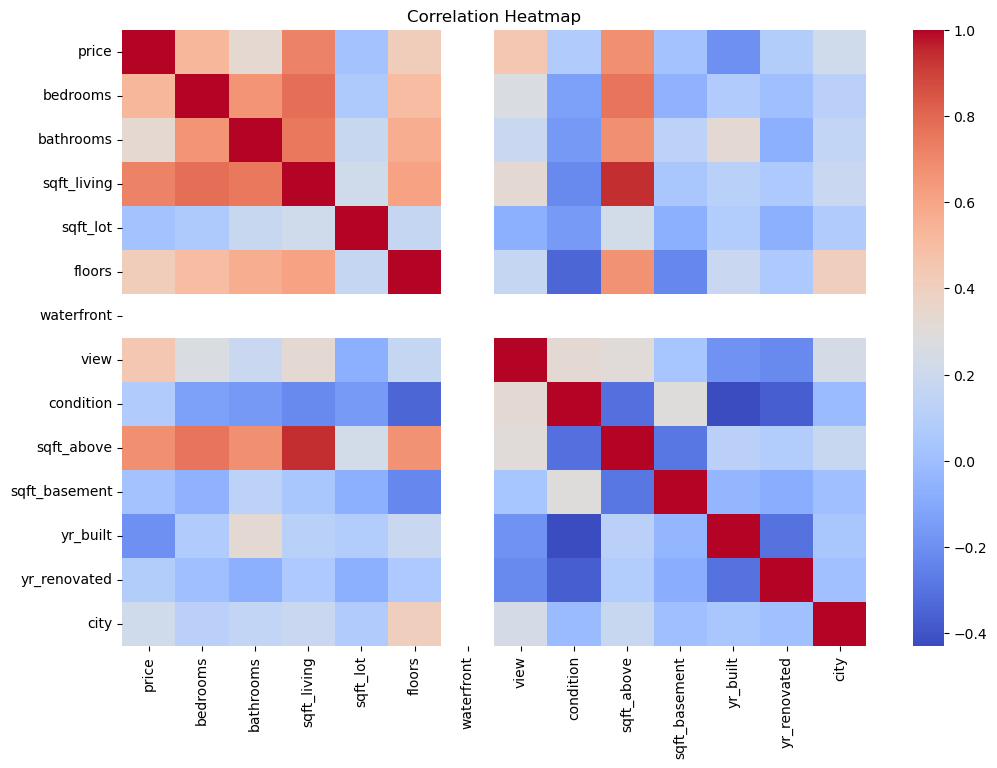

In [40]:
# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

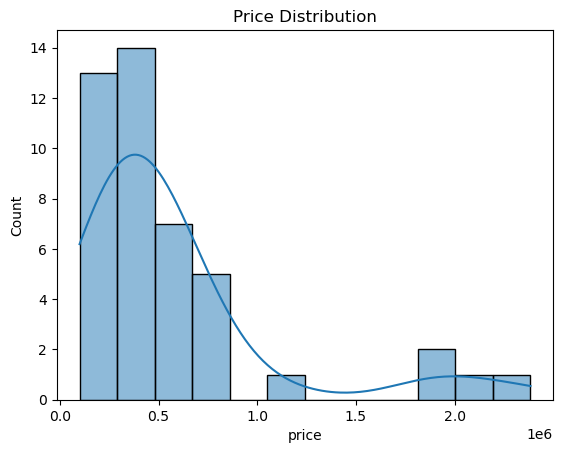

In [41]:
# Price Distribution
#Histogram 

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

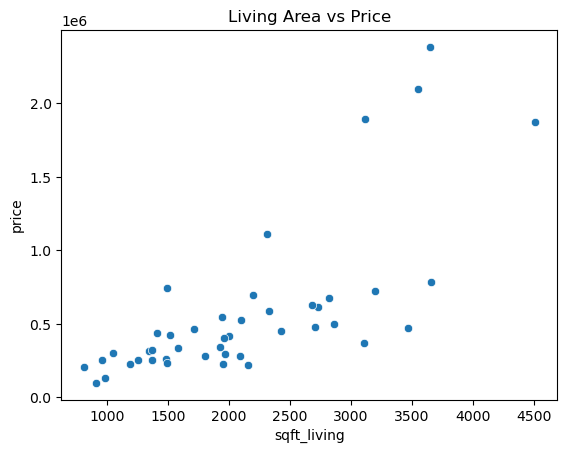

In [42]:
# living Area and Price
# Scatterplot 

sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title("Living Area vs Price")
plt.show()

# Feature Selection

In [54]:

X = df.drop('price', axis=1)
y = df['price']

In [73]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📦 Training Data: {X_train.shape}")
print(f"📦 Testing Data: {X_test.shape}")


📦 Training Data: (35, 13)
📦 Testing Data: (9, 13)


In [76]:
# Feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train)
print(X_test)

[[-0.50495552  0.14567141 -0.10325461 -0.29812669 -0.98782916  0.
  -0.28718326  0.58834841 -1.02241392  2.81149994 -0.30453582 -0.86601702
  -1.30877898]
 [-0.50495552  0.57054635  0.38541895  1.17535716 -0.98782916  0.
  -0.28718326  0.58834841 -0.39131374  2.33873571  0.55127652 -0.86601702
   0.5053701 ]
 [ 1.70422489  3.11979599  2.74923522 -0.16717438  1.10756603  0.
  -0.28718326 -0.78446454  2.86383454 -0.56538743 -0.07113245  1.1559013
   0.20301192]
 [-1.60954573 -1.97870329 -1.34198526 -0.04208697 -0.98782916  0.
  -0.28718326 -0.78446454 -1.12206132 -0.56538743 -0.57683974  1.15489135
  -1.53554761]
 [-0.50495552 -0.70407847 -0.33054464 -0.02187138 -0.98782916  0.
  -0.28718326 -0.78446454 -0.13665929 -0.56538743 -0.11003301  1.15085155
  -1.0064208 ]
 [-0.50495552  0.14567141 -0.58056367 -0.14811344 -0.98782916  0.
  -0.28718326  0.58834841 -0.38024181 -0.56538743  0.27897259  1.1538814
  -0.55288353]
 [ 0.59963468  0.14567141  0.12403541 -0.23911109  0.05986843  0.
  -0.2

# Linear Regression

In [80]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [ ]:
# Random Forest

In [81]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n✅ Models Trained Successfully!")



✅ Models Trained Successfully!


In [66]:
print(df.columns)


Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city'],
      dtype='object')


# Visualization

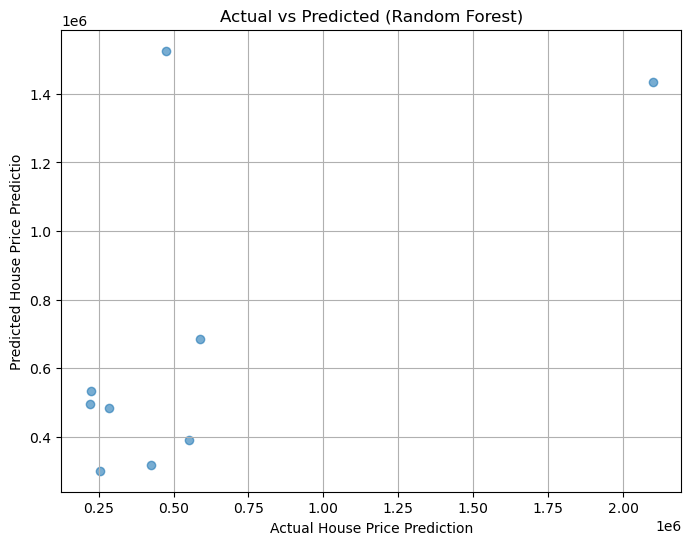

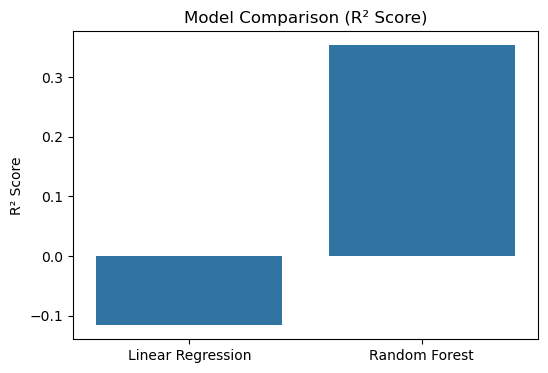

In [68]:
# Step 8: Visualization - Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Actual House Price Prediction")
plt.ylabel("Predicted House Price Predictio")
plt.title("Actual vs Predicted (Random Forest)")
plt.grid(True)
plt.show()

# Comparison of models by R2
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)]
plt.figure(figsize=(6,4))
sns.barplot(x=models, y=r2_scores)
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()


# Model Evaluation

In [64]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📈 {model_name} Performance:")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")



📈 Linear Regression Performance:
MAE : 390525.77
MSE : 346506641028.51
RMSE: 588648.15
R² Score: -0.1163

📈 Random Forest Performance:
MAE : 323141.38
MSE : 200590339826.37
RMSE: 447873.13
R² Score: 0.3538


 # Evaluation

In [67]:
print("Linear Regression Performance:")
evaluate(y_test, y_pred_lr)

Linear Regression Performance:
R2 Score: -0.11629794480902378
MAE: 390525.772255188
RMSE: 588648.1470526432


In [61]:
print("\nRandom Forest Performance:")
evaluate(y_test, y_pred_rf)


Random Forest Performance:
R2 Score: 0.35378270548557655
MAE: 323141.3822222223
RMSE: 447873.1291631297


# Model Comparison

In [62]:

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)],
    'MAE': [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_rf)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_rf))]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,-0.116298,390525.772255,588648.147053
1,Random Forest,0.353783,323141.382222,447873.129163


# Sample Prediction

In [63]:
sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 1435675.16


# Compare Performance

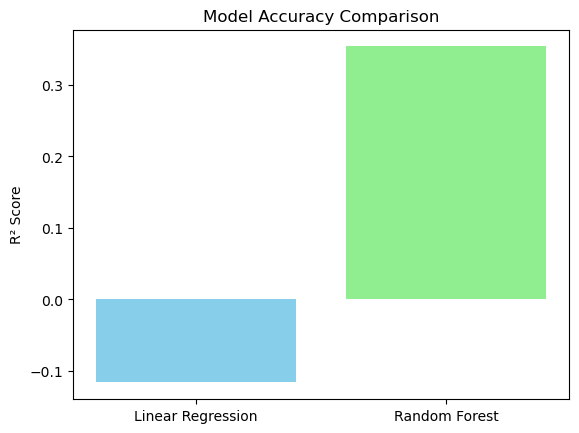

In [91]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, r2_scores, color=['skyblue', 'lightgreen'])
plt.ylabel("R² Score")
plt.title("Model Accuracy Comparison")
plt.show()

In [90]:

predicted_value = rf.predict(sample)
print("Predicted House Price Prediction:", predicted_value[0])


Predicted House Price Prediction: 1435675.16


# Actual and Predicted

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


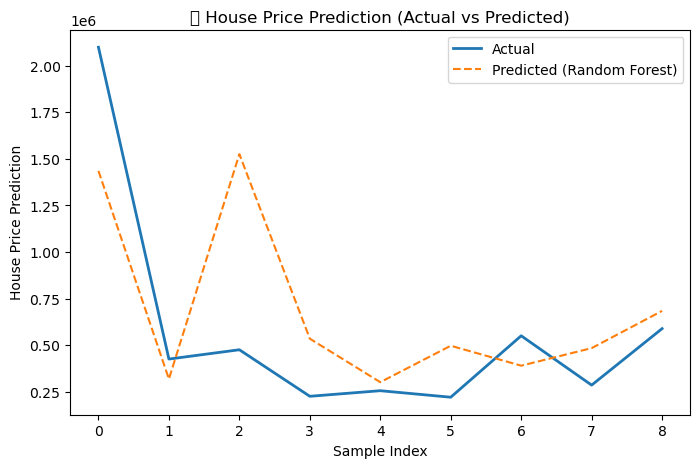


✅ Project Completed Successfully!


In [89]:
# House Price Prediction

plt.figure(figsize=(8,5))
plt.plot(y_test.values[:100], label='Actual', linewidth=2)
plt.plot(y_pred_rf[:100], label='Predicted (Random Forest)', linestyle='dashed')
plt.title("🔋 House Price Prediction (Actual vs Predicted)")
plt.xlabel("Sample Index")
plt.ylabel("House Price Prediction")
plt.legend()
plt.show()

print("\n✅ Project Completed Successfully!")